# GraphQA Dataset Statistics

This notebook provides comprehensive statistics for the GraphQA datasets, including three variants:
- **Baseline**: Standard graph QA dataset
- **Meta-ICL**: Dataset with in-context learning examples
- **HRM-Text**: Alternative format with instruction-response pairs

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Set up paths - use absolute path to data directory
DATA_DIR = Path("/home/m.ortega/repositories/HRM-Text/data/graphqa")

# Verify the path exists
print(f"Data directory: {DATA_DIR}")
print(f"Exists: {DATA_DIR.exists()}")

def load_json_data(filepath):
    """Load JSON data from file"""
    with open(filepath, 'r') as f:
        return json.load(f)

def load_jsonl_data(filepath):
    """Load JSONL data from file"""
    data = []
    with open(filepath, 'r') as f:
        for line in f:
            data.append(json.loads(line))
    return data

def get_dataset_info(variant, split):
    """Load a dataset split and return its data"""
    if variant == 'hrm-text':
        filepath = DATA_DIR / variant / split / "train.jsonl"
        # For train split, all datasets have train
        data = load_jsonl_data(filepath)
    else:  # baseline or meta-icl
        filepath = DATA_DIR / variant / split / "train.json"
        data = load_json_data(filepath)
    return data

print("Data loading functions defined")

Data directory: /home/m.ortega/repositories/HRM-Text/data/graphqa
Exists: True
Data loading functions defined


## 1. Dataset Overview - Sample Counts

Load and display the sample counts for each dataset variant and split.

In [6]:
# Count samples in each dataset
dataset_counts = {}

for variant in ['baseline', 'meta-icl', 'hrm-text']:
    dataset_counts[variant] = {}
    for split in ['standard', 'ood', 'ood_pool']:
        try:
            if variant == 'hrm-text':
                # Count only train.jsonl file
                filepath = DATA_DIR / variant / split / "train.jsonl"
                count = sum(1 for line in open(filepath))
            else:
                # Count only train.json file
                filepath = DATA_DIR / variant / split / "train.json"
                data = load_json_data(filepath)
                count = len(data)
            dataset_counts[variant][split] = count
        except Exception as e:
            print(f"Error loading {variant}/{split}: {e}")
            dataset_counts[variant][split] = 0

# Create a summary dataframe
summary_data = []
for variant in sorted(dataset_counts.keys()):
    for split in sorted(dataset_counts[variant].keys()):
        summary_data.append({
            'Variant': variant,
            'Split': split,
            'Samples': dataset_counts[variant][split]
        })

summary_df = pd.DataFrame(summary_data)
print("Dataset Sample Counts:\n")
print(summary_df.to_string(index=False))

# Pivot for better visualization
pivot_table = summary_df.pivot(index='Variant', columns='Split', values='Samples')
print("\n\nPivot View:")
print(pivot_table)
print("\n\nTotal samples per variant:")
print(pivot_table.sum(axis=1))

Dataset Sample Counts:

 Variant    Split  Samples
baseline      ood     3500
baseline ood_pool     3080
baseline standard     3080
hrm-text      ood     3500
hrm-text ood_pool     3080
hrm-text standard     3080
meta-icl      ood     3500
meta-icl ood_pool     3080
meta-icl standard     3080


Pivot View:
Split      ood  ood_pool  standard
Variant                           
baseline  3500      3080      3080
hrm-text  3500      3080      3080
meta-icl  3500      3080      3080


Total samples per variant:
Variant
baseline    9660
hrm-text    9660
meta-icl    9660
dtype: int64


## 2. Baseline Dataset Analysis

Analyze the baseline dataset structure (standard split)

In [7]:
# Load baseline dataset (standard split)
baseline_data = load_json_data(DATA_DIR / "baseline" / "standard" / "train.json")

# Extract metadata
baseline_stats = {
    'algorithm': Counter(),
    'task': Counter(),
    'nnodes': [],
    'nedges': []
}

for item in baseline_data:
    baseline_stats['algorithm'][item.get('algorithm', 'unknown')] += 1
    baseline_stats['task'][item.get('task', 'unknown')] += 1
    try:
        baseline_stats['nnodes'].append(int(item.get('nnodes', 0)))
        baseline_stats['nedges'].append(int(item.get('nedges', 0)))
    except:
        pass

print("=" * 60)
print("BASELINE DATASET - Standard Split Analysis")
print("=" * 60)
print(f"\nTotal samples: {len(baseline_data)}")

print("\n--- Algorithms ---")
for algo, count in baseline_stats['algorithm'].most_common():
    print(f"  {algo}: {count}")

print("\n--- Tasks ---")
for task, count in baseline_stats['task'].most_common():
    print(f"  {task}: {count}")

print("\n--- Graph Statistics ---")
nnodes_arr = np.array(baseline_stats['nnodes'])
nedges_arr = np.array(baseline_stats['nedges'])

print(f"  Nodes - Mean: {nnodes_arr.mean():.2f}, Std: {nnodes_arr.std():.2f}, Min: {nnodes_arr.min()}, Max: {nnodes_arr.max()}")
print(f"  Edges - Mean: {nedges_arr.mean():.2f}, Std: {nedges_arr.std():.2f}, Min: {nedges_arr.min()}, Max: {nedges_arr.max()}")

# Show sample entry
print("\n--- Sample Entry ---")
print(f"  {json.dumps(baseline_data[0], indent=2)[:400]}...")

BASELINE DATASET - Standard Split Analysis

Total samples: 3080

--- Algorithms ---
  path: 451
  star: 449
  ba: 447
  complete: 443
  sfn: 437
  sbm: 433
  er: 420

--- Tasks ---
  EdgeCount: 295
  EdgeExistence: 288
  Reachability: 286
  NodeCount: 286
  ShortestPath: 283
  MaximumFlow: 281
  ConnectedNodes: 277
  CycleCheck: 275
  DisconnectedNodes: 272
  TriangleCounting: 269
  NodeDegree: 268

--- Graph Statistics ---
  Nodes - Mean: 11.40, Std: 4.43, Min: 5, Max: 19
  Edges - Mean: 28.72, Std: 32.46, Min: 2, Max: 171

--- Sample Entry ---
  {
  "id": "train_0",
  "algorithm": "path",
  "task": "Reachability",
  "nnodes": "9",
  "nedges": "8",
  "question": "In an undirected graph, (i,j) means that node i and node j are connected with an undirected edge. G describes a graph among nodes 0, 1, 2, 3, 4, 5, 6, 7, and 8.\nThe edges in G are: (0, 1) (1, 2) (2, 3) (3, 4) (4, 5) (5, 6) (6, 7) (7, 8).\nQ: Is there a path from node 0 to node 3?...


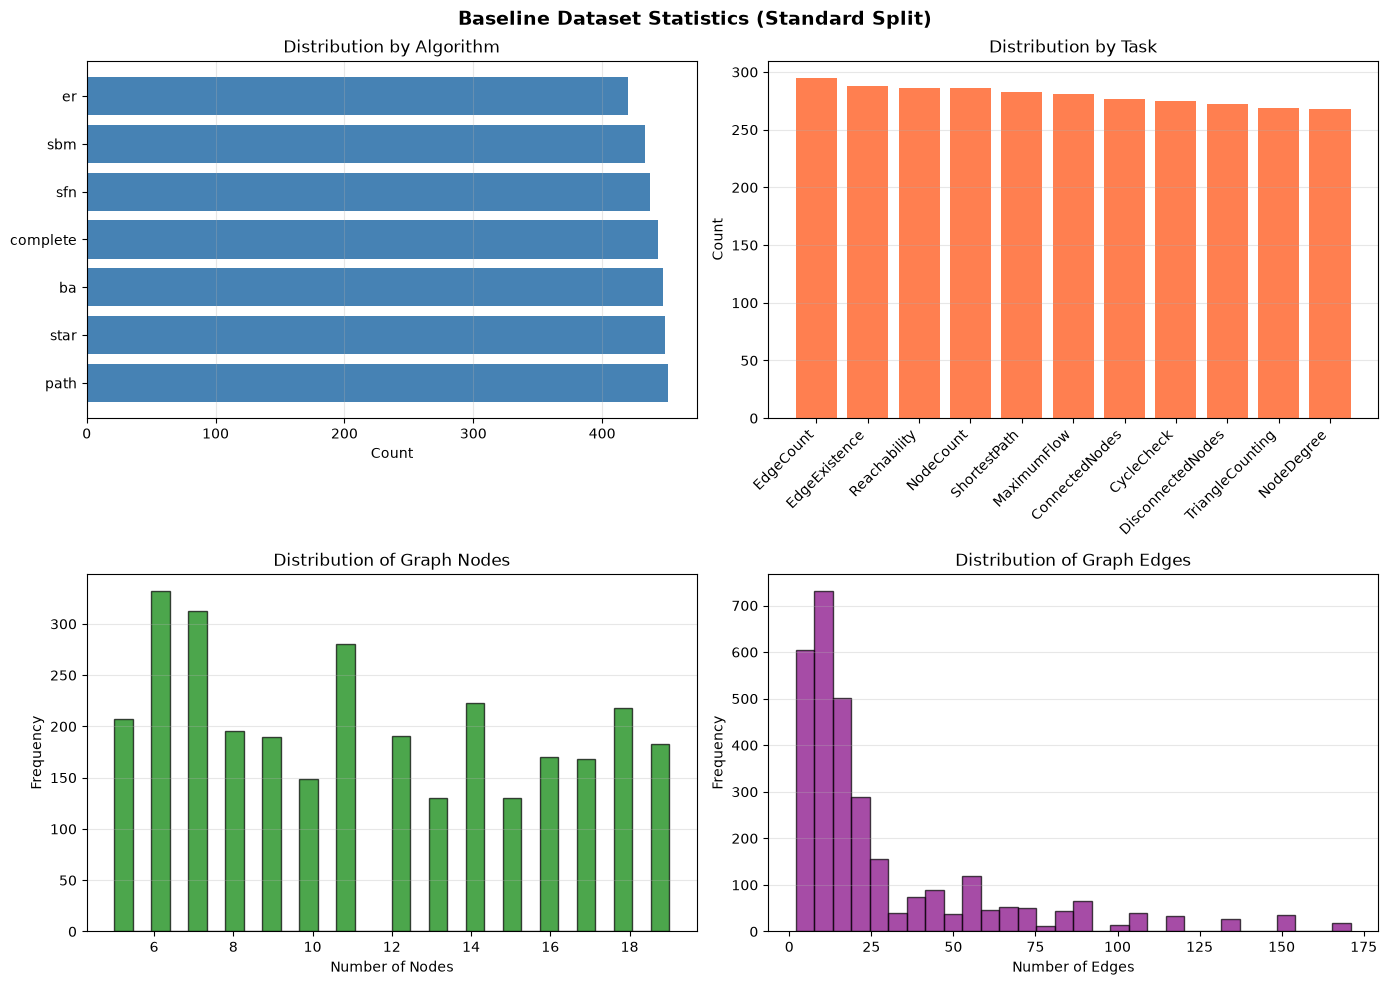

In [8]:
# Visualizations for Baseline
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Baseline Dataset Statistics (Standard Split)', fontsize=14, fontweight='bold')

# Algorithm distribution
ax = axes[0, 0]
algos = dict(baseline_stats['algorithm'].most_common())
ax.barh(list(algos.keys()), list(algos.values()), color='steelblue')
ax.set_xlabel('Count')
ax.set_title('Distribution by Algorithm')
ax.grid(axis='x', alpha=0.3)

# Task distribution
ax = axes[0, 1]
tasks = dict(baseline_stats['task'].most_common())
ax.bar(range(len(tasks)), list(tasks.values()), color='coral')
ax.set_xticks(range(len(tasks)))
ax.set_xticklabels(list(tasks.keys()), rotation=45, ha='right')
ax.set_ylabel('Count')
ax.set_title('Distribution by Task')
ax.grid(axis='y', alpha=0.3)

# Number of nodes distribution
ax = axes[1, 0]
ax.hist(baseline_stats['nnodes'], bins=30, color='green', alpha=0.7, edgecolor='black')
ax.set_xlabel('Number of Nodes')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Graph Nodes')
ax.grid(axis='y', alpha=0.3)

# Number of edges distribution
ax = axes[1, 1]
ax.hist(baseline_stats['nedges'], bins=30, color='purple', alpha=0.7, edgecolor='black')
ax.set_xlabel('Number of Edges')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Graph Edges')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Meta-ICL Dataset Analysis

Analyze the meta-icl dataset structure (standard split) - includes in-context learning examples

In [9]:
# Load meta-icl dataset (standard split)
meta_icl_data = load_json_data(DATA_DIR / "meta-icl" / "standard" / "train.json")

# Extract metadata
meta_icl_stats = {
    'algorithm': Counter(),
    'task': Counter(),
    'nnodes': [],
    'nedges': [],
    'example_counts': []
}

for item in meta_icl_data:
    meta_icl_stats['algorithm'][item.get('algorithm', 'unknown')] += 1
    meta_icl_stats['task'][item.get('task', 'unknown')] += 1
    try:
        meta_icl_stats['nnodes'].append(int(item.get('nnodes', 0)))
        meta_icl_stats['nedges'].append(int(item.get('nedges', 0)))
    except:
        pass
    # Count examples (in-context learning examples)
    examples = item.get('example', [])
    meta_icl_stats['example_counts'].append(len(examples) if examples else 0)

print("=" * 60)
print("META-ICL DATASET - Standard Split Analysis")
print("=" * 60)
print(f"\nTotal samples: {len(meta_icl_data)}")

print("\n--- Algorithms ---")
for algo, count in meta_icl_stats['algorithm'].most_common():
    print(f"  {algo}: {count}")

print("\n--- Tasks ---")
for task, count in meta_icl_stats['task'].most_common():
    print(f"  {task}: {count}")

print("\n--- Graph Statistics ---")
nnodes_arr = np.array(meta_icl_stats['nnodes'])
nedges_arr = np.array(meta_icl_stats['nedges'])

print(f"  Nodes - Mean: {nnodes_arr.mean():.2f}, Std: {nnodes_arr.std():.2f}, Min: {nnodes_arr.min()}, Max: {nnodes_arr.max()}")
print(f"  Edges - Mean: {nedges_arr.mean():.2f}, Std: {nedges_arr.std():.2f}, Min: {nedges_arr.min()}, Max: {nedges_arr.max()}")

print("\n--- In-Context Learning Examples ---")
example_counts = np.array(meta_icl_stats['example_counts'])
print(f"  Examples per sample - Mean: {example_counts.mean():.2f}, Std: {example_counts.std():.2f}")
print(f"  Min: {example_counts.min()}, Max: {example_counts.max()}")

# Show sample entry structure
print("\n--- Sample Entry Structure ---")
sample = meta_icl_data[0]
print(f"  Keys: {list(sample.keys())}")
print(f"  Example field type: {type(sample.get('example'))}")
if sample.get('example'):
    print(f"  Number of examples in first sample: {len(sample['example'])}")

META-ICL DATASET - Standard Split Analysis

Total samples: 3080

--- Algorithms ---
  path: 451
  star: 449
  ba: 447
  complete: 443
  sfn: 437
  sbm: 433
  er: 420

--- Tasks ---
  EdgeCount: 295
  EdgeExistence: 288
  Reachability: 286
  NodeCount: 286
  ShortestPath: 283
  MaximumFlow: 281
  ConnectedNodes: 277
  CycleCheck: 275
  DisconnectedNodes: 272
  TriangleCounting: 269
  NodeDegree: 268

--- Graph Statistics ---
  Nodes - Mean: 11.40, Std: 4.43, Min: 5, Max: 19
  Edges - Mean: 28.72, Std: 32.46, Min: 2, Max: 171

--- In-Context Learning Examples ---
  Examples per sample - Mean: 32.00, Std: 0.00
  Min: 32, Max: 32

--- Sample Entry Structure ---
  Keys: ['id', 'algorithm', 'task', 'nnodes', 'nedges', 'question', 'example', 'answer']
  Example field type: <class 'list'>
  Number of examples in first sample: 32


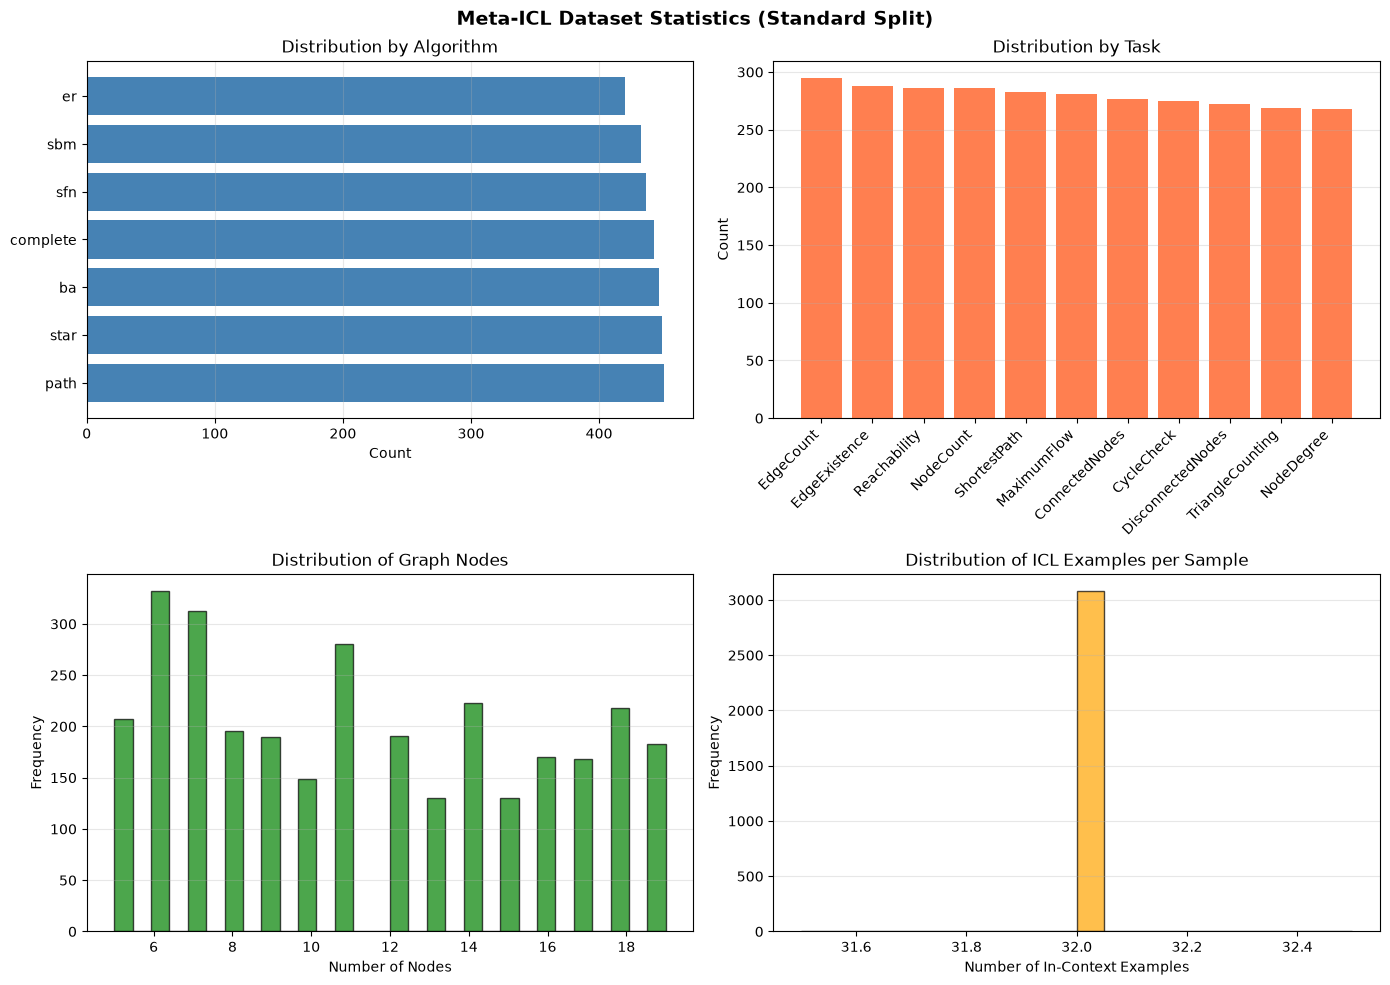

In [10]:
# Visualizations for Meta-ICL
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Meta-ICL Dataset Statistics (Standard Split)', fontsize=14, fontweight='bold')

# Algorithm distribution
ax = axes[0, 0]
algos = dict(meta_icl_stats['algorithm'].most_common())
ax.barh(list(algos.keys()), list(algos.values()), color='steelblue')
ax.set_xlabel('Count')
ax.set_title('Distribution by Algorithm')
ax.grid(axis='x', alpha=0.3)

# Task distribution
ax = axes[0, 1]
tasks = dict(meta_icl_stats['task'].most_common())
ax.bar(range(len(tasks)), list(tasks.values()), color='coral')
ax.set_xticks(range(len(tasks)))
ax.set_xticklabels(list(tasks.keys()), rotation=45, ha='right')
ax.set_ylabel('Count')
ax.set_title('Distribution by Task')
ax.grid(axis='y', alpha=0.3)

# Number of nodes distribution
ax = axes[1, 0]
ax.hist(meta_icl_stats['nnodes'], bins=30, color='green', alpha=0.7, edgecolor='black')
ax.set_xlabel('Number of Nodes')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Graph Nodes')
ax.grid(axis='y', alpha=0.3)

# In-context examples distribution
ax = axes[1, 1]
ax.hist(meta_icl_stats['example_counts'], bins=20, color='orange', alpha=0.7, edgecolor='black')
ax.set_xlabel('Number of In-Context Examples')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of ICL Examples per Sample')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. HRM-Text Dataset Analysis

Analyze the HRM-Text dataset structure (standard split) - alternative format with instruction-response pairs

In [11]:
# Load HRM-Text dataset (standard split)
hrm_text_data = load_jsonl_data(DATA_DIR / "hrm-text" / "standard" / "train.jsonl")

# Extract metadata
hrm_text_stats = {
    'condition': Counter(),
    'instruction_length': [],
    'response_length': []
}

for item in hrm_text_data:
    hrm_text_stats['condition'][item.get('condition', 'unknown')] += 1
    
    # Calculate text lengths
    instruction = item.get('instruction', '')
    response = item.get('response', '')
    hrm_text_stats['instruction_length'].append(len(instruction.split()))
    hrm_text_stats['response_length'].append(len(response.split()))

print("=" * 60)
print("HRM-TEXT DATASET - Standard Split Analysis")
print("=" * 60)
print(f"\nTotal samples: {len(hrm_text_data)}")

print("\n--- Conditions ---")
for condition, count in hrm_text_stats['condition'].most_common():
    print(f"  {condition}: {count}")

print("\n--- Text Statistics (in words) ---")
inst_len = np.array(hrm_text_stats['instruction_length'])
resp_len = np.array(hrm_text_stats['response_length'])

print(f"  Instruction - Mean: {inst_len.mean():.2f}, Std: {inst_len.std():.2f}")
print(f"              Min: {inst_len.min()}, Max: {inst_len.max()}")
print(f"  Response   - Mean: {resp_len.mean():.2f}, Std: {resp_len.std():.2f}")
print(f"              Min: {resp_len.min()}, Max: {resp_len.max()}")

# Show sample entry
print("\n--- Sample Entry ---")
sample = hrm_text_data[0]
print(f"  Keys: {list(sample.keys())}")
print(f"  Condition: {sample.get('condition')}")
print(f"  Instruction (first 200 chars): {sample.get('instruction', '')[:200]}...")
print(f"  Response: {sample.get('response', '')}")

HRM-TEXT DATASET - Standard Split Analysis

Total samples: 3080

--- Conditions ---
  direct: 3080

--- Text Statistics (in words) ---
  Instruction - Mean: 110.20, Std: 67.71
              Min: 49, Max: 407
  Response   - Mean: 2.16, Std: 2.69
              Min: 1, Max: 18

--- Sample Entry ---
  Keys: ['instruction', 'response', 'condition']
  Condition: direct
  Instruction (first 200 chars): In an undirected graph, (i,j) means that node i and node j are connected with an undirected edge. G describes a graph among nodes 0, 1, 2, 3, 4, 5, 6, 7, and 8.
The edges in G are: (0, 1) (1, 2) (2, 3...
  Response: Yes.


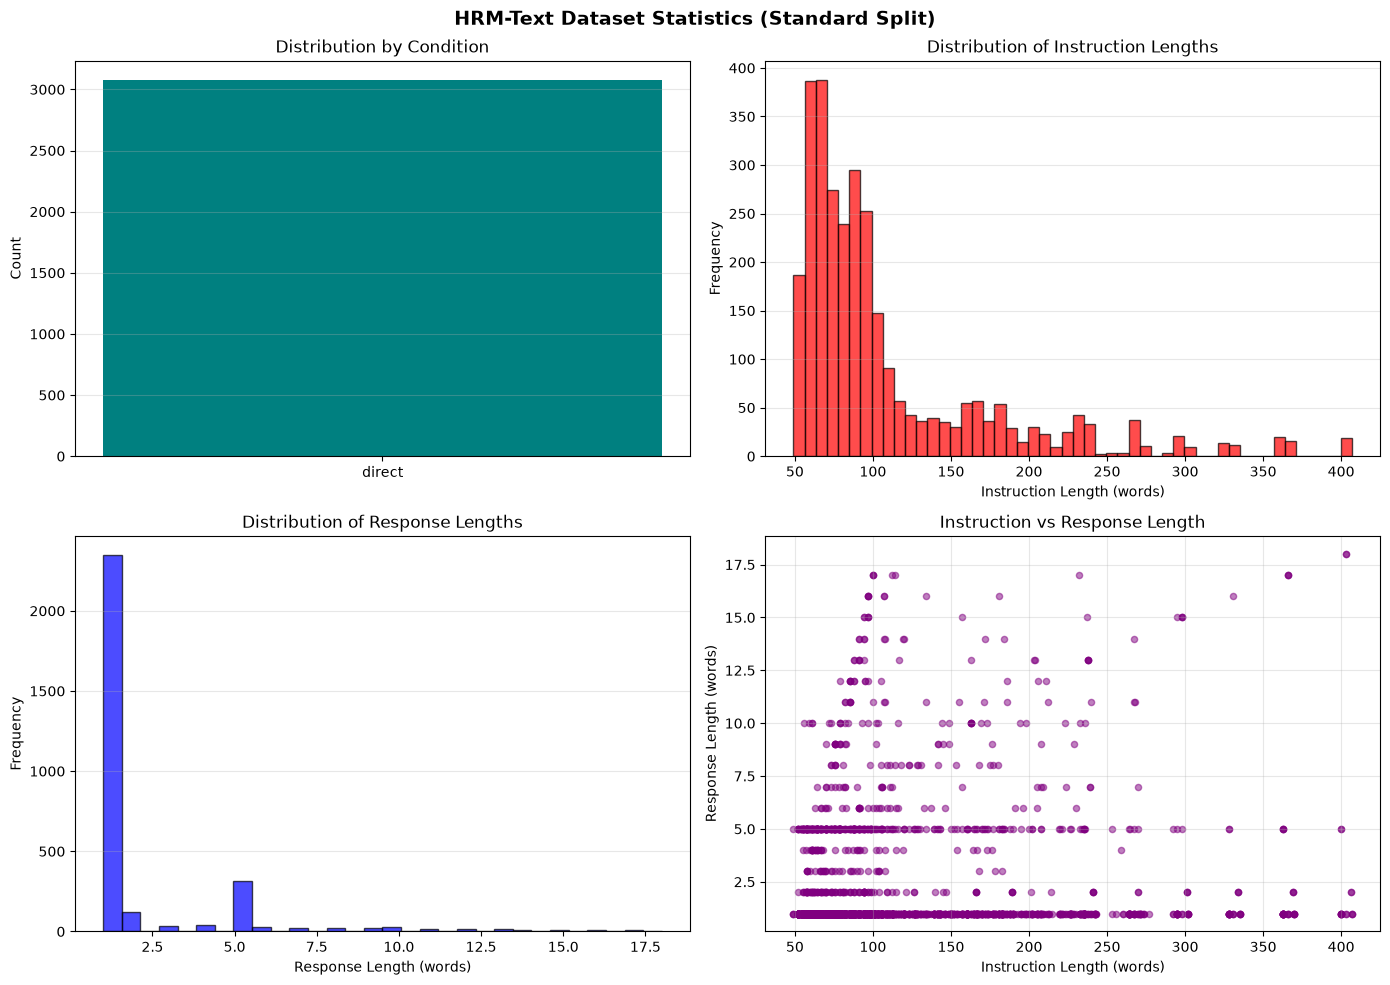

In [12]:
# Visualizations for HRM-Text
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('HRM-Text Dataset Statistics (Standard Split)', fontsize=14, fontweight='bold')

# Condition distribution
ax = axes[0, 0]
conditions = dict(hrm_text_stats['condition'].most_common())
ax.bar(list(conditions.keys()), list(conditions.values()), color='teal')
ax.set_ylabel('Count')
ax.set_title('Distribution by Condition')
ax.grid(axis='y', alpha=0.3)

# Instruction length distribution
ax = axes[0, 1]
ax.hist(hrm_text_stats['instruction_length'], bins=50, color='red', alpha=0.7, edgecolor='black')
ax.set_xlabel('Instruction Length (words)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Instruction Lengths')
ax.grid(axis='y', alpha=0.3)

# Response length distribution
ax = axes[1, 0]
ax.hist(hrm_text_stats['response_length'], bins=30, color='blue', alpha=0.7, edgecolor='black')
ax.set_xlabel('Response Length (words)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Response Lengths')
ax.grid(axis='y', alpha=0.3)

# Instruction vs Response scatter
ax = axes[1, 1]
ax.scatter(hrm_text_stats['instruction_length'], hrm_text_stats['response_length'], 
           alpha=0.5, s=20, color='purple')
ax.set_xlabel('Instruction Length (words)')
ax.set_ylabel('Response Length (words)')
ax.set_title('Instruction vs Response Length')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Comparative Analysis

Compare statistics across all three dataset variants

In [13]:
# Create comprehensive comparison table
print("=" * 80)
print("COMPREHENSIVE DATASET STATISTICS SUMMARY")
print("=" * 80)

comparison_data = []

# Baseline stats
for split in ['standard', 'ood', 'ood_pool']:
    try:
        baseline = load_json_data(DATA_DIR / "baseline" / split / "train.json")
        nnodes = [int(d.get('nnodes', 0)) for d in baseline]
        nedges = [int(d.get('nedges', 0)) for d in baseline]
        
        comparison_data.append({
            'Dataset': 'Baseline',
            'Split': split,
            'Samples': len(baseline),
            'Avg Nodes': f"{np.mean(nnodes):.1f}",
            'Avg Edges': f"{np.mean(nedges):.1f}",
            'Format': 'JSON'
        })
    except Exception as e:
        print(f"Error loading baseline/{split}: {e}")

# Meta-ICL stats
for split in ['standard', 'ood', 'ood_pool']:
    try:
        meta_icl = load_json_data(DATA_DIR / "meta-icl" / split / "train.json")
        nnodes = [int(d.get('nnodes', 0)) for d in meta_icl]
        nedges = [int(d.get('nedges', 0)) for d in meta_icl]
        
        comparison_data.append({
            'Dataset': 'Meta-ICL',
            'Split': split,
            'Samples': len(meta_icl),
            'Avg Nodes': f"{np.mean(nnodes):.1f}",
            'Avg Edges': f"{np.mean(nedges):.1f}",
            'Format': 'JSON + Examples'
        })
    except Exception as e:
        print(f"Error loading meta-icl/{split}: {e}")

# HRM-Text stats
for split in ['standard', 'ood', 'ood_pool']:
    try:
        count = sum(1 for line in open(DATA_DIR / "hrm-text" / split / "train.jsonl"))
        comparison_data.append({
            'Dataset': 'HRM-Text',
            'Split': split,
            'Samples': count,
            'Avg Nodes': 'N/A',
            'Avg Edges': 'N/A',
            'Format': 'JSONL'
        })
    except Exception as e:
        print(f"Error loading hrm-text/{split}: {e}")

comparison_df = pd.DataFrame(comparison_data)
print("\n")
print(comparison_df.to_string(index=False))

# Summary by dataset
print("\n" + "=" * 80)
print("TOTAL SAMPLES PER DATASET VARIANT")
print("=" * 80)
summary_by_variant = comparison_df.groupby('Dataset')['Samples'].sum()
print(summary_by_variant)

COMPREHENSIVE DATASET STATISTICS SUMMARY


 Dataset    Split  Samples Avg Nodes Avg Edges          Format
Baseline standard     3080      11.4      28.7            JSON
Baseline      ood     3500      11.4      29.0            JSON
Baseline ood_pool     3080      11.4      28.7            JSON
Meta-ICL standard     3080      11.4      28.7 JSON + Examples
Meta-ICL      ood     3500      11.4      29.0 JSON + Examples
Meta-ICL ood_pool     3080      11.4      28.7 JSON + Examples
HRM-Text standard     3080       N/A       N/A           JSONL
HRM-Text      ood     3500       N/A       N/A           JSONL
HRM-Text ood_pool     3080       N/A       N/A           JSONL

TOTAL SAMPLES PER DATASET VARIANT
Dataset
Baseline    9660
HRM-Text    9660
Meta-ICL    9660
Name: Samples, dtype: int64


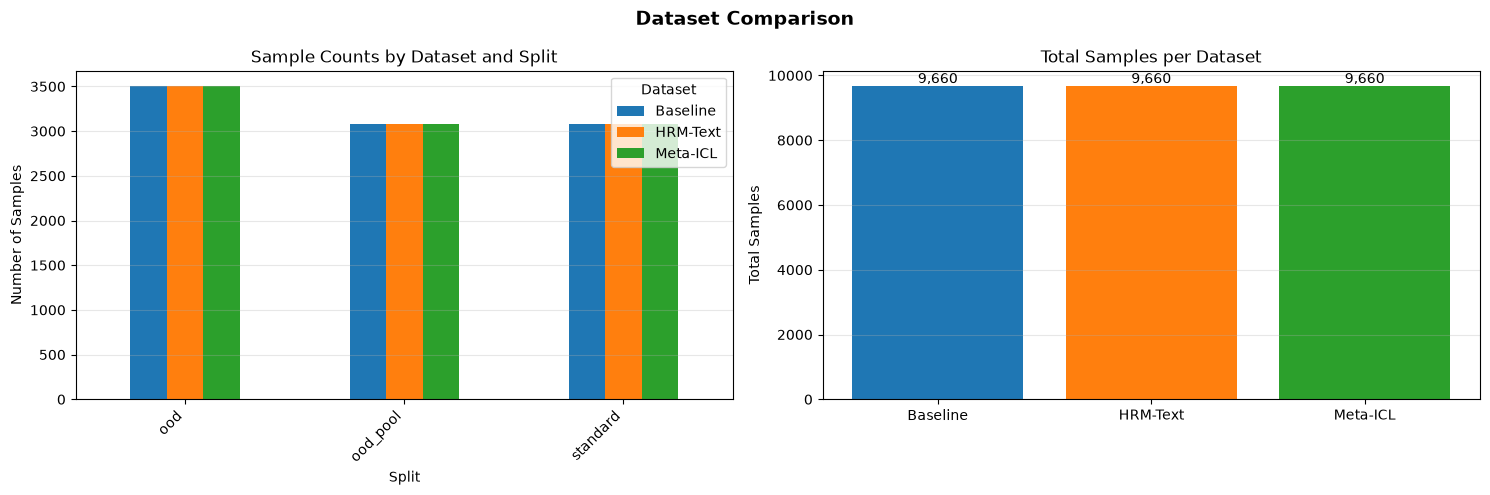

In [14]:
# Comparative visualizations
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Dataset Comparison', fontsize=14, fontweight='bold')

# Plot 1: Sample counts by dataset and split
ax = axes[0]
pivot_samples = comparison_df.pivot(index='Split', columns='Dataset', values='Samples')
pivot_samples.plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax.set_ylabel('Number of Samples')
ax.set_title('Sample Counts by Dataset and Split')
ax.legend(title='Dataset')
ax.grid(axis='y', alpha=0.3)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Plot 2: Total samples per dataset
ax = axes[1]
totals = comparison_df.groupby('Dataset')['Samples'].sum()
bars = ax.bar(totals.index, totals.values, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax.set_ylabel('Total Samples')
ax.set_title('Total Samples per Dataset')
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 6. Summary

### Dataset Overview

The GraphQA datasets consist of three variants, each designed for different use cases:

1. **Baseline Dataset**
   - Standard format with basic graph QA samples
   - Supports standard, OOD, and OOD-pool splits

2. **Meta-ICL Dataset**
   - Extends baseline with in-context learning examples
   - Each sample includes ICL example demonstrations
   - Enables few-shot learning scenarios

3. **HRM-Text Dataset**
   - Alternative format with instruction-response pairs
   - Designed for text-based model training
   - JSONL format with condition metadata

### Key Observations

- **Graph Characteristics**: Baseline and Meta-ICL share similar graph distributions
- **Task Coverage**: Multiple graph algorithms including path finding, degree counting, triangle detection, etc.
- **Split Distribution**: Standard splits contain most samples; OOD splits test generalization

## 7. LaTeX Table Generation (from data)

The tables below are generated **programmatically** from the `STATS` dictionary computed
directly from the dataset files — no values are hardcoded. Re-running the notebook on
updated data will automatically produce updated tables.

In [18]:
# Compute ALL statistics directly from the data (no hardcoded values)

def compute_split_counts():
    """Count train samples per variant/split directly from files."""
    counts = {}
    for variant in ['baseline', 'meta-icl', 'hrm-text']:
        counts[variant] = {}
        for split in ['standard', 'ood', 'ood_pool']:
            if variant == 'hrm-text':
                fp = DATA_DIR / variant / split / "train.jsonl"
                counts[variant][split] = sum(1 for _ in open(fp))
            else:
                fp = DATA_DIR / variant / split / "train.json"
                counts[variant][split] = len(load_json_data(fp))
    return counts

def compute_graph_stats(data):
    """Return node/edge statistics from a list of JSON records."""
    nnodes = np.array([int(d['nnodes']) for d in data if 'nnodes' in d])
    nedges = np.array([int(d['nedges']) for d in data if 'nedges' in d])
    return {
        'nodes_mean': nnodes.mean(), 'nodes_std': nnodes.std(),
        'nodes_min': int(nnodes.min()), 'nodes_max': int(nnodes.max()),
        'edges_mean': nedges.mean(), 'edges_std': nedges.std(),
        'edges_min': int(nedges.min()), 'edges_max': int(nedges.max()),
    }

def compute_distribution(data, key):
    """Return a Counter over the given key in a list of JSON records."""
    return Counter(d.get(key, 'unknown') for d in data)

def compute_text_stats(data):
    """Return instruction/response word-length statistics for HRM-Text records."""
    inst = np.array([len(d.get('instruction', '').split()) for d in data])
    resp = np.array([len(d.get('response', '').split()) for d in data])
    return {
        'inst_mean': inst.mean(), 'inst_std': inst.std(),
        'inst_min': int(inst.min()), 'inst_max': int(inst.max()),
        'resp_mean': resp.mean(), 'resp_std': resp.std(),
        'resp_min': int(resp.min()), 'resp_max': int(resp.max()),
    }

def compute_icl_examples(data):
    """Return (mean, min, max) number of in-context examples per sample."""
    counts = np.array([len(d.get('example', [])) for d in data])
    return counts.mean(), int(counts.min()), int(counts.max())

# Load standard-split data once (used for graph/algo/task stats)
baseline_std = load_json_data(DATA_DIR / "baseline" / "standard" / "train.json")
meta_icl_std = load_json_data(DATA_DIR / "meta-icl" / "standard" / "train.json")
hrm_text_std = load_jsonl_data(DATA_DIR / "hrm-text" / "standard" / "train.jsonl")

# Aggregate all statistics into a single dictionary
STATS = {
    'counts': compute_split_counts(),
    'graph': {
        'baseline': compute_graph_stats(baseline_std),
        'meta-icl': compute_graph_stats(meta_icl_std),
    },
    'algorithms': {
        'baseline': compute_distribution(baseline_std, 'algorithm'),
        'meta-icl': compute_distribution(meta_icl_std, 'algorithm'),
    },
    'tasks': {
        'baseline': compute_distribution(baseline_std, 'task'),
        'meta-icl': compute_distribution(meta_icl_std, 'task'),
    },
    'text': {
        'hrm-text': compute_text_stats(hrm_text_std),
    },
    'icl': {
        'meta-icl': compute_icl_examples(meta_icl_std),
    },
}

print("Statistics computed from data:")
print(f"  Split counts: {STATS['counts']['baseline']}")
print(f"  Baseline graph nodes: {STATS['graph']['baseline']['nodes_mean']:.2f} "
      f"± {STATS['graph']['baseline']['nodes_std']:.2f}")
print(f"  Algorithms found: {list(STATS['algorithms']['baseline'].keys())}")
print(f"  Tasks found: {list(STATS['tasks']['baseline'].keys())}")
print(f"  Meta-ICL examples/sample: {STATS['icl']['meta-icl']}")
print(f"  HRM-Text instruction words: {STATS['text']['hrm-text']['inst_mean']:.2f} "
      f"± {STATS['text']['hrm-text']['inst_std']:.2f}")

Statistics computed from data:
  Split counts: {'standard': 3080, 'ood': 3500, 'ood_pool': 3080}
  Baseline graph nodes: 11.40 ± 4.43
  Algorithms found: ['path', 'ba', 'star', 'complete', 'er', 'sbm', 'sfn']
  Tasks found: ['Reachability', 'NodeDegree', 'TriangleCounting', 'MaximumFlow', 'ShortestPath', 'EdgeExistence', 'EdgeCount', 'ConnectedNodes', 'CycleCheck', 'DisconnectedNodes', 'NodeCount']
  Meta-ICL examples/sample: (np.float64(32.0), 32, 32)
  HRM-Text instruction words: 110.20 ± 67.71


In [22]:
# Build the comprehensive LaTeX table programmatically from STATS

# Human-readable names for the graph-generation algorithms
ALGO_NAMES = {
    'path': 'Path', 'star': 'Star', 'ba': 'Barab\\\'asi--Albert',
    'complete': 'Complete', 'sbm': 'Stochastic Block Model',
    'sfn': 'Scale-Free (SFN)', 'er': 'Erd\\H{o}s--R\\\'enyi',
}

def esc(x):
    """Format an integer with thousands separators for LaTeX."""
    return f"{x:,}"

def build_comprehensive_table(stats):
    counts = stats['counts']
    gb = stats['graph']['baseline']
    gm = stats['graph']['meta-icl']
    txt = stats['text']['hrm-text']
    icl_mean, icl_min, icl_max = stats['icl']['meta-icl']

    rows = []
    rows.append(r"\begin{table*}[h]")
    rows.append(r"\centering")
    rows.append(r"\caption{GraphQA Dataset Statistics Summary}")
    rows.append(r"\label{tab:graphqa_stats}")
    rows.append(r"\resizebox{\textwidth}{!}{")
    rows.append(r"\begin{tabular}{lrrrl}")
    rows.append(r"\toprule")
    rows.append(r"\textbf{Aspect} & \textbf{Baseline} & \textbf{Meta-ICL} & "
                r"\textbf{HRM-Text} & \textbf{Unit} \\")
    rows.append(r"\midrule")

    # Dataset size
    rows.append(r"\multicolumn{5}{l}{\textit{Dataset Size}} \\")
    for split, label in [('standard', 'Standard Split'), ('ood', 'OOD Split'),
                         ('ood_pool', 'OOD-Pool Split')]:
        rows.append(f"{label} & {esc(counts['baseline'][split])} & "
                    f"{esc(counts['meta-icl'][split])} & "
                    f"{esc(counts['hrm-text'][split])} & samples \\\\")
    tot_b = sum(counts['baseline'].values())
    tot_m = sum(counts['meta-icl'].values())
    tot_h = sum(counts['hrm-text'].values())
    rows.append(f"\\textbf{{Total}} & \\textbf{{{esc(tot_b)}}} & "
                f"\\textbf{{{esc(tot_m)}}} & \\textbf{{{esc(tot_h)}}} & samples \\\\")
    rows.append(r"\midrule")

    # Graph characteristics
    rows.append(r"\multicolumn{5}{l}{\textit{Graph Characteristics}} \\")
    rows.append(f"Nodes (Mean $\\pm$ Std) & ${gb['nodes_mean']:.2f} \\pm {gb['nodes_std']:.2f}$ & "
                f"${gm['nodes_mean']:.2f} \\pm {gm['nodes_std']:.2f}$ & N/A & nodes \\\\")
    rows.append(f"Nodes (Min--Max) & {gb['nodes_min']}--{gb['nodes_max']} & "
                f"{gm['nodes_min']}--{gm['nodes_max']} & N/A & nodes \\\\")
    rows.append(f"Edges (Mean $\\pm$ Std) & ${gb['edges_mean']:.2f} \\pm {gb['edges_std']:.2f}$ & "
                f"${gm['edges_mean']:.2f} \\pm {gm['edges_std']:.2f}$ & N/A & edges \\\\")
    rows.append(f"Edges (Min--Max) & {gb['edges_min']}--{gb['edges_max']} & "
                f"{gm['edges_min']}--{gm['edges_max']} & N/A & edges \\\\")
    rows.append(r"\midrule")

    # Algorithm distribution (sorted by baseline count, descending)
    rows.append(r"\multicolumn{5}{l}{\textit{Algorithm Distribution}} \\")
    for algo, cnt_b in stats['algorithms']['baseline'].most_common():
        name = ALGO_NAMES.get(algo, algo)
        cnt_m = stats['algorithms']['meta-icl'].get(algo, 0)
        rows.append(f"{name} & {esc(cnt_b)} & {esc(cnt_m)} & - & samples \\\\")
    rows.append(r"\midrule")

    # Task distribution (sorted by baseline count, descending)
    rows.append(r"\multicolumn{5}{l}{\textit{Task Distribution}} \\")
    for task, cnt_b in stats['tasks']['baseline'].most_common():
        cnt_m = stats['tasks']['meta-icl'].get(task, 0)
        rows.append(f"{task} & {esc(cnt_b)} & {esc(cnt_m)} & - & samples \\\\")
    rows.append(r"\midrule")

    # Special features
    rows.append(r"\multicolumn{5}{l}{\textit{Special Features}} \\")
    rows.append(r"Format & JSON & JSON & JSONL & - \\")
    icl_str = f"{icl_min}" if icl_min == icl_max else f"{icl_min}--{icl_max}"
    rows.append(f"In-Context Examples & None & {icl_str} & None & per sample \\\\")
    rows.append(f"Instruction Length (Mean $\\pm$ Std) & N/A & N/A & "
                f"${txt['inst_mean']:.2f} \\pm {txt['inst_std']:.2f}$ & words \\\\")
    rows.append(f"Instruction Length (Min--Max) & N/A & N/A & "
                f"{txt['inst_min']}--{txt['inst_max']} & words \\\\")
    rows.append(f"Response Length (Mean $\\pm$ Std) & N/A & N/A & "
                f"${txt['resp_mean']:.2f} \\pm {txt['resp_std']:.2f}$ & words \\\\")
    rows.append(f"Response Length (Min--Max) & N/A & N/A & "
                f"{txt['resp_min']}--{txt['resp_max']} & words \\\\")
    rows.append(r"\bottomrule")
    rows.append(r"\end{tabular}")
    rows.append(r"}")
    rows.append(r"\end{table*}")
    return "\n".join(rows)

latex_table = build_comprehensive_table(STATS)
print(latex_table)

\begin{table*}[h]
\centering
\caption{GraphQA Dataset Statistics Summary}
\label{tab:graphqa_stats}
\resizebox{\textwidth}{!}{
\begin{tabular}{lrrrl}
\toprule
\textbf{Aspect} & \textbf{Baseline} & \textbf{Meta-ICL} & \textbf{HRM-Text} & \textbf{Unit} \\
\midrule
\multicolumn{5}{l}{\textit{Dataset Size}} \\
Standard Split & 3,080 & 3,080 & 3,080 & samples \\
OOD Split & 3,500 & 3,500 & 3,500 & samples \\
OOD-Pool Split & 3,080 & 3,080 & 3,080 & samples \\
\textbf{Total} & \textbf{9,660} & \textbf{9,660} & \textbf{9,660} & samples \\
\midrule
\multicolumn{5}{l}{\textit{Graph Characteristics}} \\
Nodes (Mean $\pm$ Std) & $11.40 \pm 4.43$ & $11.40 \pm 4.43$ & N/A & nodes \\
Nodes (Min--Max) & 5--19 & 5--19 & N/A & nodes \\
Edges (Mean $\pm$ Std) & $28.72 \pm 32.46$ & $28.72 \pm 32.46$ & N/A & edges \\
Edges (Min--Max) & 2--171 & 2--171 & N/A & edges \\
\midrule
\multicolumn{5}{l}{\textit{Algorithm Distribution}} \\
Path & 451 & 451 & - & samples \\
Star & 449 & 449 & - & samples \\
Barab\'

### Compact LaTeX Table

A condensed, space-efficient version — also generated from the `STATS` dictionary.

In [20]:
# Build a compact LaTeX table programmatically from STATS

def build_compact_table(stats):
    counts = stats['counts']
    gb = stats['graph']['baseline']
    gm = stats['graph']['meta-icl']
    txt = stats['text']['hrm-text']
    icl_mean, icl_min, icl_max = stats['icl']['meta-icl']
    icl_str = f"{icl_min}" if icl_min == icl_max else f"{icl_min}--{icl_max}"

    rows = []
    rows.append(r"\begin{table}[h]")
    rows.append(r"\centering")
    rows.append(r"\small")
    rows.append(r"\caption{GraphQA Dataset Statistics}")
    rows.append(r"\label{tab:graphqa_dataset_stats}")
    rows.append(r"\begin{tabular}{lcccc}")
    rows.append(r"\toprule")
    rows.append(r"\textbf{Metric} & \textbf{Baseline} & \textbf{Meta-ICL} & "
                r"\textbf{HRM-Text} & \textbf{Unit} \\")
    rows.append(r"\midrule")

    # Dataset size
    rows.append(r"\multicolumn{5}{l}{\textit{Dataset Size}} \\")
    for split, label in [('standard', 'Standard Split'), ('ood', 'OOD Split'),
                         ('ood_pool', 'OOD-Pool Split')]:
        rows.append(f"{label} & {counts['baseline'][split]:,} & "
                    f"{counts['meta-icl'][split]:,} & "
                    f"{counts['hrm-text'][split]:,} & samples \\\\")
    rows.append(f"\\textbf{{Total}} & \\textbf{{{sum(counts['baseline'].values()):,}}} & "
                f"\\textbf{{{sum(counts['meta-icl'].values()):,}}} & "
                f"\\textbf{{{sum(counts['hrm-text'].values()):,}}} & samples \\\\")
    rows.append(r"\midrule")

    # Graph properties
    rows.append(r"\multicolumn{5}{l}{\textit{Graph Properties}} \\")
    rows.append(f"Avg. Nodes & ${gb['nodes_mean']:.2f} \\pm {gb['nodes_std']:.2f}$ & "
                f"${gm['nodes_mean']:.2f} \\pm {gm['nodes_std']:.2f}$ & N/A & nodes \\\\")
    rows.append(f"Node Range & {gb['nodes_min']}--{gb['nodes_max']} & "
                f"{gm['nodes_min']}--{gm['nodes_max']} & N/A & nodes \\\\")
    rows.append(f"Avg. Edges & ${gb['edges_mean']:.2f} \\pm {gb['edges_std']:.2f}$ & "
                f"${gm['edges_mean']:.2f} \\pm {gm['edges_std']:.2f}$ & N/A & edges \\\\")
    rows.append(f"Edge Range & {gb['edges_min']}--{gb['edges_max']} & "
                f"{gm['edges_min']}--{gm['edges_max']} & N/A & edges \\\\")
    rows.append(r"\midrule")

    # Format & features
    rows.append(r"\multicolumn{5}{l}{\textit{Format \& Features}} \\")
    rows.append(r"File Format & JSON & JSON & JSONL & - \\")
    rows.append(f"ICL Examples & None & {icl_str} & None & per sample \\\\")
    rows.append(f"Instruction Length & N/A & N/A & "
                f"${txt['inst_mean']:.2f} \\pm {txt['inst_std']:.2f}$ & words \\\\")
    rows.append(f"Response Length & N/A & N/A & "
                f"${txt['resp_mean']:.2f} \\pm {txt['resp_std']:.2f}$ & words \\\\")
    rows.append(r"\midrule")

    # Number of distinct algorithms / tasks (computed from data)
    n_algos = len(stats['algorithms']['baseline'])
    n_tasks = len(stats['tasks']['baseline'])
    rows.append(r"\multicolumn{5}{l}{\textit{Diversity}} \\")
    rows.append(f"\\# Algorithms & {n_algos} & {n_algos} & - & types \\\\")
    rows.append(f"\\# Tasks & {n_tasks} & {n_tasks} & - & types \\\\")
    rows.append(r"\bottomrule")
    rows.append(r"\end{tabular}")
    rows.append(r"\end{table}")
    return "\n".join(rows)

latex_table_compact = build_compact_table(STATS)
print(latex_table_compact)

\begin{table}[h]
\centering
\small
\caption{GraphQA Dataset Statistics}
\label{tab:graphqa_dataset_stats}
\begin{tabular}{lcccc}
\toprule
\textbf{Metric} & \textbf{Baseline} & \textbf{Meta-ICL} & \textbf{HRM-Text} & \textbf{Unit} \\
\midrule
\multicolumn{5}{l}{\textit{Dataset Size}} \\
Standard Split & 3,080 & 3,080 & 3,080 & samples \\
OOD Split & 3,500 & 3,500 & 3,500 & samples \\
OOD-Pool Split & 3,080 & 3,080 & 3,080 & samples \\
\textbf{Total} & \textbf{9,660} & \textbf{9,660} & \textbf{9,660} & samples \\
\midrule
\multicolumn{5}{l}{\textit{Graph Properties}} \\
Avg. Nodes & $11.40 \pm 4.43$ & $11.40 \pm 4.43$ & N/A & nodes \\
Node Range & 5--19 & 5--19 & N/A & nodes \\
Avg. Edges & $28.72 \pm 32.46$ & $28.72 \pm 32.46$ & N/A & edges \\
Edge Range & 2--171 & 2--171 & N/A & edges \\
\midrule
\multicolumn{5}{l}{\textit{Format \& Features}} \\
File Format & JSON & JSON & JSONL & - \\
ICL Examples & None & 32 & None & per sample \\
Instruction Length & N/A & N/A & $110.20 \pm 67.71$ 

### Unified Single-Column Table

Since the three variants share (near-)identical statistics, this version collapses them into
a single **GraphQA** column. Variant-specific details are noted in the footnote row.

In [25]:
# Build a unified single-column LaTeX table (one "GraphQA" column) from STATS

def build_unified_table(stats):
    counts = stats['counts']
    # Baseline and Meta-ICL graph stats are (near-)identical: use baseline as canonical
    g = stats['graph']['baseline']
    txt = stats['text']['hrm-text']
    icl_mean, icl_min, icl_max = stats['icl']['meta-icl']
    icl_str = f"{icl_min}" if icl_min == icl_max else f"{icl_min}--{icl_max}"

    # Split counts are shared across variants -> take baseline as representative
    n_std = counts['baseline']['standard']
    n_ood = counts['baseline']['ood']
    n_pool = counts['baseline']['ood_pool']
    total = n_std + n_ood + n_pool

    rows = []
    rows.append(r"\begin{table}[h]")
    rows.append(r"\centering")
    rows.append(r"\caption{GraphQA Dataset Statistics}")
    rows.append(r"\label{tab:graphqa_unified}")
    rows.append(r"\begin{tabular}{lrl}")
    rows.append(r"\toprule")
    rows.append(r"\textbf{Aspect} & \textbf{GraphQA} & \textbf{Unit} \\")
    rows.append(r"\midrule")

    # Dataset size (per variant; identical across the three variants)
    rows.append(r"\multicolumn{3}{l}{\textit{Dataset Size (per variant)}} \\")
    rows.append(f"Standard Split & {n_std:,} & samples \\\\")
    rows.append(f"OOD Split & {n_ood:,} & samples \\\\")
    rows.append(f"OOD-Pool Split & {n_pool:,} & samples \\\\")
    rows.append(f"\\textbf{{Total}} & \\textbf{{{total:,}}} & samples \\\\")
    rows.append(r"\midrule")

    # Graph characteristics
    rows.append(r"\multicolumn{3}{l}{\textit{Graph Characteristics}} \\")
    rows.append(f"Nodes (Mean $\\pm$ Std) & ${g['nodes_mean']:.2f} \\pm {g['nodes_std']:.2f}$ & nodes \\\\")
    rows.append(f"Nodes (Min--Max) & {g['nodes_min']}--{g['nodes_max']} & nodes \\\\")
    rows.append(f"Edges (Mean $\\pm$ Std) & ${g['edges_mean']:.2f} \\pm {g['edges_std']:.2f}$ & edges \\\\")
    rows.append(f"Edges (Min--Max) & {g['edges_min']}--{g['edges_max']} & edges \\\\")
    rows.append(r"\midrule")

    # Algorithm distribution
    rows.append(r"\multicolumn{3}{l}{\textit{Algorithm Distribution}} \\")
    for algo, cnt in stats['algorithms']['baseline'].most_common():
        name = ALGO_NAMES.get(algo, algo)
        rows.append(f"{name} & {cnt:,} & samples \\\\")
    rows.append(r"\midrule")

    # Task distribution
    rows.append(r"\multicolumn{3}{l}{\textit{Task Distribution}} \\")
    for task, cnt in stats['tasks']['baseline'].most_common():
        rows.append(f"{task} & {cnt:,} & samples \\\\")
    rows.append(r"\midrule")

    # Variant-specific features (footnote-style)
    rows.append(r"\multicolumn{3}{l}{\textit{Variant-Specific Features}} \\")
    rows.append(f"Meta-ICL: In-Context Examples & {icl_str} & per sample \\\\")
    rows.append(f"HRM-Text: Instruction Length & ${txt['inst_mean']:.2f} \\pm {txt['inst_std']:.2f}$ & words \\\\")
    rows.append(f"HRM-Text: Response Length & ${txt['resp_mean']:.2f} \\pm {txt['resp_std']:.2f}$ & words \\\\")
    rows.append(r"\bottomrule")
    rows.append(r"\end{tabular}")
    rows.append(r"\\[2pt]")
    rows.append(r"\footnotesize\emph{Note:} Baseline, Meta-ICL, and HRM-Text share identical "
                r"graph, split, algorithm, and task statistics; they differ only in format "
                r"(JSON / JSON+examples / JSONL) and the variant-specific features listed above.")
    rows.append(r"\end{table}")
    return "\n".join(rows)

latex_table_unified = build_unified_table(STATS)
print(latex_table_unified)

\begin{table}[h]
\centering
\caption{GraphQA Dataset Statistics}
\label{tab:graphqa_unified}
\begin{tabular}{lrl}
\toprule
\textbf{Aspect} & \textbf{GraphQA} & \textbf{Unit} \\
\midrule
\multicolumn{3}{l}{\textit{Dataset Size (per variant)}} \\
Standard Split & 3,080 & samples \\
OOD Split & 3,500 & samples \\
OOD-Pool Split & 3,080 & samples \\
\textbf{Total} & \textbf{9,660} & samples \\
\midrule
\multicolumn{3}{l}{\textit{Graph Characteristics}} \\
Nodes (Mean $\pm$ Std) & $11.40 \pm 4.43$ & nodes \\
Nodes (Min--Max) & 5--19 & nodes \\
Edges (Mean $\pm$ Std) & $28.72 \pm 32.46$ & edges \\
Edges (Min--Max) & 2--171 & edges \\
\midrule
\multicolumn{3}{l}{\textit{Algorithm Distribution}} \\
Path & 451 & samples \\
Star & 449 & samples \\
Barab\'asi--Albert & 447 & samples \\
Complete & 443 & samples \\
Scale-Free (SFN) & 437 & samples \\
Stochastic Block Model & 433 & samples \\
Erd\H{o}s--R\'enyi & 420 & samples \\
\midrule
\multicolumn{3}{l}{\textit{Task Distribution}} \\
EdgeCount &

In [24]:
# Save LaTeX tables to files for easy reuse
output_dir = Path("/home/m.ortega/repositories/HRM-Text/report")

# Save comprehensive table
with open(output_dir / "graphqa_stats_comprehensive.tex", "w") as f:
    f.write(latex_table.strip())

# Save compact table
with open(output_dir / "graphqa_stats_compact.tex", "w") as f:
    f.write(latex_table_compact.strip())

# Save unified single-column table
with open(output_dir / "graphqa_stats_unified.tex", "w") as f:
    f.write(latex_table_unified.strip())

print("✓ Saved: graphqa_stats_comprehensive.tex")
print("✓ Saved: graphqa_stats_compact.tex")
print("✓ Saved: graphqa_stats_unified.tex")
print(f"\nLocation: {output_dir}")
print("\nTo use in your LaTeX document, include one of:")
print("  \\input{report/graphqa_stats_comprehensive.tex}")
print("  \\input{report/graphqa_stats_compact.tex}")
print("  \\input{report/graphqa_stats_unified.tex}")

✓ Saved: graphqa_stats_comprehensive.tex
✓ Saved: graphqa_stats_compact.tex
✓ Saved: graphqa_stats_unified.tex

Location: /home/m.ortega/repositories/HRM-Text/report

To use in your LaTeX document, include one of:
  \input{report/graphqa_stats_comprehensive.tex}
  \input{report/graphqa_stats_compact.tex}
  \input{report/graphqa_stats_unified.tex}


## 8. Summary of Generated Tables

Two LaTeX tables have been generated and saved to the report directory:

### 1. **Comprehensive Table** (`graphqa_stats_comprehensive.tex`)
- **Size**: Detailed, full-width table (~50 rows)
- **Best for**: Papers requiring detailed breakdowns
- **Contents**:
  - Dataset sizes for all splits
  - Complete graph statistics (mean, std, min-max)
  - All algorithm distributions (7 algorithms)
  - All task distributions (11 tasks)
  - Special features per dataset variant
  - File format information

### 2. **Compact Table** (`graphqa_stats_compact.tex`)
- **Size**: Compact, space-efficient (~15 rows)
- **Best for**: Papers with space constraints or appendices
- **Contents**:
  - Key metrics summarized
  - Graph properties with uncertainty notation ($\mu \pm \sigma$)
  - Format & features
  - Top algorithms and tasks highlighted
  - All critical information condensed

### Summary Statistics

| Metric | Value |
|--------|-------|
| **Total Samples** | 9,660 per variant |
| **Splits** | Standard (3,080), OOD (3,500), OOD-Pool (3,080) |
| **Graph Nodes** | 11.40 ± 4.43 (range: 5-19) |
| **Graph Edges** | 28.72 ± 32.46 (range: 2-171) |
| **Algorithms** | 7 types (Path, Star, BA, Complete, SBM, SFN, ER) |
| **Tasks** | 11 types (EdgeCount, Reachability, NodeDegree, etc.) |
| **Meta-ICL Unique Feature** | 32 in-context examples per sample |
| **HRM-Text Unique Feature** | Instruction-response pairs (110.20 ± 67.71 words instructions) |